In [3]:
!pip install -q gradio nltk

In [4]:
import warnings
warnings.filterwarnings("ignore")

import re, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tf.random.set_seed(42)
np.random.seed(42)



In [7]:
df_raw = pd.read_csv("/kaggle/input/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/complaints_processed.csv")
df_raw = df_raw.drop(columns=[c for c in df_raw.columns if c.startswith("Unnamed")], errors="ignore")
print(df_raw.shape)
df_raw.head()

(162421, 2)


,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


In [8]:
df = df_raw.dropna(subset=["narrative", "product"]).drop_duplicates(subset=["narrative"]).reset_index(drop=True)
print("after delete:", df.shape)

STOPWORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()                              
    text = re.sub(r"[^a-z\s]", " ", text)             
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]   
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]                  
    return " ".join(tokens)

print("before:", df['narrative'].iloc[0][:150])
print("after:", clean_text(df['narrative'].iloc[0])[:150])

after delete: (124472, 2)
before: purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im s
after: purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded sorr


product
credit_reporting       56240
debt_collection        21057
mortgages_and_loans    18723
credit_card            14983
retail_banking         13469
Name: count, dtype: int64


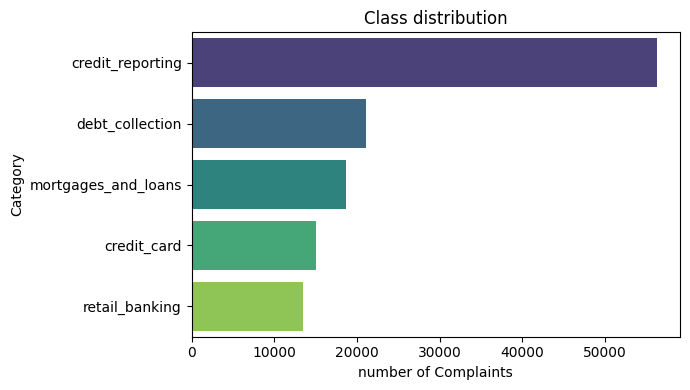

In [9]:
dist = df['product'].value_counts()
print(dist)

plt.figure(figsize=(7,4))
sns.barplot(x=dist.values, y=dist.index, palette="viridis")
plt.title("Class distribution")
plt.xlabel("number of Complaints"); plt.ylabel("Category")
plt.tight_layout(); plt.show()

In [10]:
SAMPLE_PER_CLASS = 15000     
VOCAB_SIZE = 20000
MAX_LEN = 100
EMBED_DIM = 128
EPOCHS = 8
BATCH_SIZE = 128

parts = []
for label, group in df.groupby("product"):
    n = min(SAMPLE_PER_CLASS, len(group))
    parts.append(group.sample(n=n, random_state=42))
df_s = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)
print(df_s['product'].value_counts())

df_s['clean_narrative'] = df_s['narrative'].apply(clean_text)
df_s = df_s[df_s['clean_narrative'].str.len() > 0].reset_index(drop=True)

le = LabelEncoder()
y = le.fit_transform(df_s['product'])
num_classes = len(le.classes_)
print("Categories:", list(le.classes_))

product
debt_collection        15000
credit_reporting       15000
mortgages_and_loans    15000
credit_card            14983
retail_banking         13469
Name: count, dtype: int64
Categories: ['credit_card', 'credit_reporting', 'debt_collection', 'mortgages_and_loans', 'retail_banking']


In [11]:
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df_s['clean_narrative'].values, y, test_size=0.3, random_state=42, stratify=y)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train/Val/Test:", len(X_train_text), len(X_val_text), len(X_test_text))

class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weight)

Train/Val/Test: 51416 11018 11018
Class weights: {0: np.float64(0.9804729214340199), 1: np.float64(0.979352380952381), 2: np.float64(0.979352380952381), 3: np.float64(0.979352380952381), 4: np.float64(1.090708527789563)}


In [12]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = to_padded(X_train_text)
X_val   = to_padded(X_val_text)
X_test  = to_padded(X_test_text)

print(X_train.shape, X_val.shape, X_test.shape)

(51416, 100) (11018, 100) (11018, 100)


In [14]:
def evaluate_model(model, name, X_test, y_test, classes):
    probs = model.predict(X_test, verbose=0)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average="weighted", zero_division=0)
    print(f"\n=== {name} ===")
    print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
    print(classification_report(y_test, preds, target_names=classes, zero_division=0))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
results = []
histories = {}

Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,576,837 (9.83 MB)

 Trainable params: 2,576,837 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
402/402 - 11s - 29ms/step - accuracy: 0.5760 - loss: 1.0594 - val_accuracy: 0.5409 - val_loss: 1.1667
Epoch 2/8
402/402 - 4s - 11ms/step - accuracy: 0.6136 - loss: 1.0197 - val_accuracy: 0.5705 - val_loss: 1.0778

=== SimpleRNN ===
Accuracy=0.5480  Precision=0.5758  Recall=0.5480  F1=0.5456
                     precision    recall  f1-score   support

        credit_card       0.45      0.54      0.50      2248
   credit_reporting       0.52      0.69      0.59      2250
    debt_collection       0.71      0.37      0.49      2250
mortgages_and_loans       0.67      0.55      0.60      2250
     retail_banking       0.51      0.59      0.55      2020

           accuracy                           0.55     11018
          macro avg       0.57      0.55      0.55     11018
       weighted avg       0.58      0.55      0.55     11018



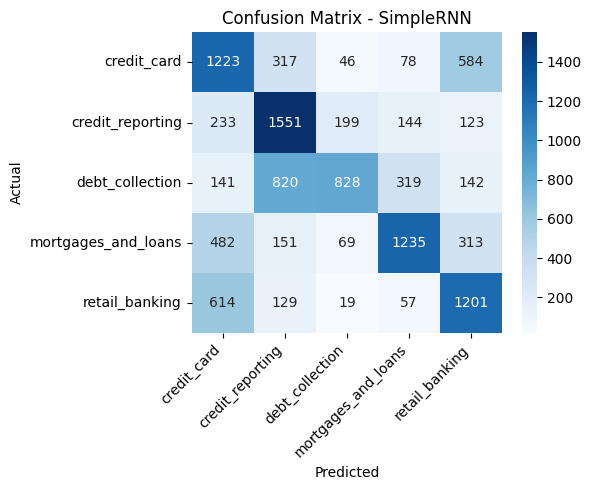

In [16]:
def build_rnn(cell_type):
    cell = {"SimpleRNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[cell_type]
    model = keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True),   # embedding layer
        cell(64, dropout=0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ], name=cell_type)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

rnn_model = build_rnn("SimpleRNN")
rnn_model.summary()
hist = rnn_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                      epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weight,
                      callbacks=[es], verbose=2)
histories["SimpleRNN"] = hist.history
results.append(evaluate_model(rnn_model, "SimpleRNN", X_test, y_test, le.classes_))

Epoch 1/8
402/402 - 9s - 23ms/step - accuracy: 0.7066 - loss: 0.8084 - val_accuracy: 0.8146 - val_loss: 0.5833
Epoch 2/8
402/402 - 4s - 11ms/step - accuracy: 0.8167 - loss: 0.5802 - val_accuracy: 0.8123 - val_loss: 0.5745
Epoch 3/8
402/402 - 5s - 11ms/step - accuracy: 0.8469 - loss: 0.4912 - val_accuracy: 0.8270 - val_loss: 0.5541
Epoch 4/8
402/402 - 4s - 11ms/step - accuracy: 0.8656 - loss: 0.4290 - val_accuracy: 0.8280 - val_loss: 0.5396
Epoch 5/8
402/402 - 4s - 11ms/step - accuracy: 0.8788 - loss: 0.3873 - val_accuracy: 0.8300 - val_loss: 0.5494
Epoch 6/8
402/402 - 4s - 11ms/step - accuracy: 0.8881 - loss: 0.3555 - val_accuracy: 0.8293 - val_loss: 0.5571

=== LSTM ===
Accuracy=0.8257  Precision=0.8286  Recall=0.8257  F1=0.8257
                     precision    recall  f1-score   support

        credit_card       0.75      0.85      0.80      2248
   credit_reporting       0.84      0.74      0.79      2250
    debt_collection       0.84      0.81      0.83      2250
mortgages_and_l

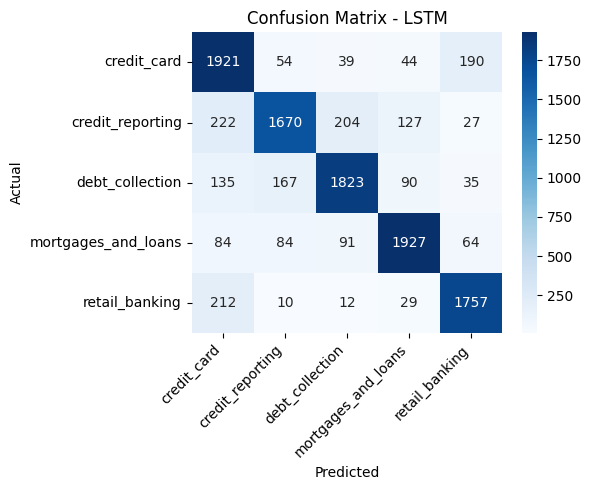

In [17]:
lstm_model = build_rnn("LSTM")
hist = lstm_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                       epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weight,
                       callbacks=[es], verbose=2)
histories["LSTM"] = hist.history
results.append(evaluate_model(lstm_model, "LSTM", X_test, y_test, le.classes_))

Epoch 1/8
402/402 - 6s - 16ms/step - accuracy: 0.6893 - loss: 0.8175 - val_accuracy: 0.8323 - val_loss: 0.5049
Epoch 2/8
402/402 - 4s - 11ms/step - accuracy: 0.8471 - loss: 0.4721 - val_accuracy: 0.8360 - val_loss: 0.4930
Epoch 3/8
402/402 - 4s - 11ms/step - accuracy: 0.8699 - loss: 0.4013 - val_accuracy: 0.8365 - val_loss: 0.4971
Epoch 4/8
402/402 - 4s - 11ms/step - accuracy: 0.8862 - loss: 0.3537 - val_accuracy: 0.8339 - val_loss: 0.5214

=== GRU ===
Accuracy=0.8383  Precision=0.8398  Recall=0.8383  F1=0.8379
                     precision    recall  f1-score   support

        credit_card       0.78      0.88      0.83      2248
   credit_reporting       0.83      0.76      0.80      2250
    debt_collection       0.85      0.80      0.83      2250
mortgages_and_loans       0.86      0.87      0.87      2250
     retail_banking       0.87      0.87      0.87      2020

           accuracy                           0.84     11018
          macro avg       0.84      0.84      0.84    

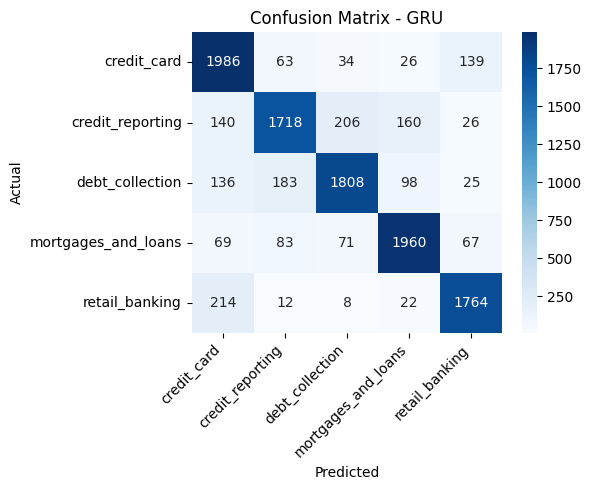

In [18]:
gru_model = build_rnn("GRU")
hist = gru_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                      epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weight,
                      callbacks=[es], verbose=2)
histories["GRU"] = hist.history
results.append(evaluate_model(gru_model, "GRU", X_test, y_test, le.classes_))

In [19]:
!pip install -q transformers[torch] datasets accelerate

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

hf_checkpoint = "distilbert-base-uncased"
hf_tokenizer = AutoTokenizer.from_pretrained(hf_checkpoint)

def hf_tokenize(batch):
    return hf_tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_ds = Dataset.from_dict({"text": list(X_train_text), "label": list(y_train)}).map(hf_tokenize, batched=True)
val_ds   = Dataset.from_dict({"text": list(X_val_text),   "label": list(y_val)}).map(hf_tokenize, batched=True)
test_ds  = Dataset.from_dict({"text": list(X_test_text),  "label": list(y_test)}).map(hf_tokenize, batched=True)

hf_model = AutoModelForSequenceClassification.from_pretrained(hf_checkpoint, num_labels=num_classes)

args = TrainingArguments(
    output_dir="hf_out",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,   
)

from sklearn.metrics import f1_score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"f1": f1_score(labels, preds, average="weighted")}

trainer = Trainer(model=hf_model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                   compute_metrics=compute_metrics)
trainer.train()
trainer.save_model("hf_distilbert_model")
hf_tokenizer.save_pretrained("hf_distilbert_model")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/51416 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('hf_distilbert_model/tokenizer_config.json',
 'hf_distilbert_model/tokenizer.json')

Accuracy=0.8587  Precision=0.8585  Recall=0.8587  F1=0.8585
                     precision    recall  f1-score   support

        credit_card       0.84      0.86      0.85      2248
   credit_reporting       0.84      0.81      0.82      2250
    debt_collection       0.85      0.83      0.84      2250
mortgages_and_loans       0.88      0.89      0.89      2250
     retail_banking       0.88      0.90      0.89      2020

           accuracy                           0.86     11018
          macro avg       0.86      0.86      0.86     11018
       weighted avg       0.86      0.86      0.86     11018



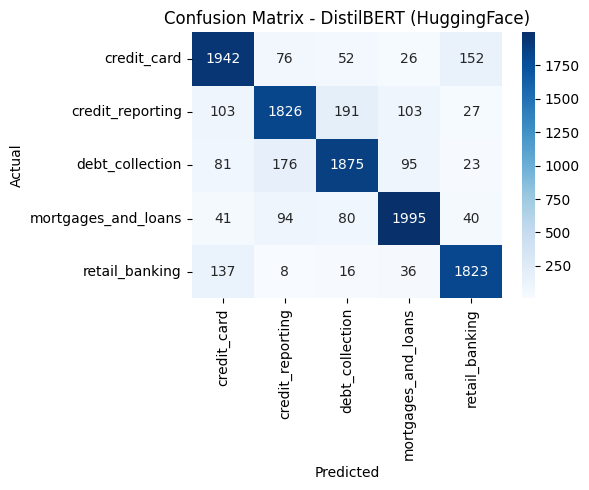

In [20]:
preds_out = trainer.predict(test_ds)
hf_preds = np.argmax(preds_out.predictions, axis=1)

acc = accuracy_score(y_test, hf_preds)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, hf_preds, average="weighted", zero_division=0)
print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
print(classification_report(y_test, hf_preds, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_test, hf_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - DistilBERT (HuggingFace)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

results.append({"model": "DistilBERT_HF", "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})

,model,accuracy,precision,recall,f1
3,DistilBERT_HF,0.858686,0.858483,0.858686,0.858485
2,GRU,0.838265,0.839848,0.838265,0.837948
1,LSTM,0.825740,0.828598,0.825740,0.825697
0,SimpleRNN,0.548012,0.575783,0.548012,0.545555


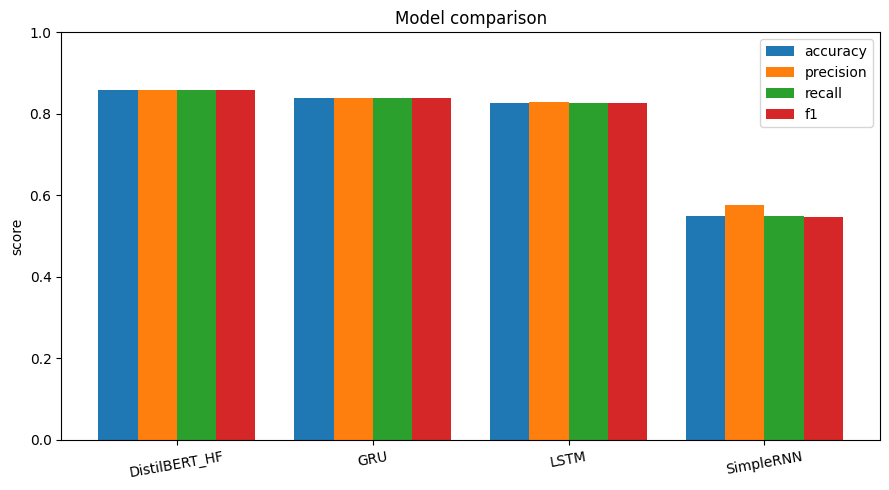

the best model: DistilBERT_HF


In [22]:
results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
display(results_df)

x = np.arange(len(results_df)); w = 0.2
plt.figure(figsize=(9,5))
for i, metric in enumerate(["accuracy","precision","recall","f1"]):
    plt.bar(x + i*w, results_df[metric], width=w, label=metric)
plt.xticks(x + 1.5*w, results_df["model"], rotation=10)
plt.ylim(0,1); plt.ylabel("score"); plt.legend()
plt.title("Model comparison")
plt.tight_layout(); plt.show()

best_name = results_df.iloc[0]["model"]
print("the best model:", best_name)

In [26]:
models_lookup = {"SimpleRNN": rnn_model, "LSTM": lstm_model, "GRU": gru_model}

def predict_complaint(text):
    if best_name == "DistilBERT_HF":
        inputs = hf_tokenizer(clean_text(text), return_tensors="pt", truncation=True, padding=True, max_length=128)
        inputs = {k: v.cuda() for k, v in inputs.items()}
        
        with torch.no_grad():
            logits = hf_model(**inputs).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    else:
        model = models_lookup[best_name]
        cleaned = clean_text(text)
        seq = tokenizer.texts_to_sequences([cleaned])
        padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
        probs = model.predict(padded, verbose=0)[0]
    idx = int(np.argmax(probs))
    return le.classes_[idx], float(probs[idx]), dict(zip(le.classes_, probs.tolist()))

sample = "A debt collector keeps calling me multiple times a day about a debt I already paid off."
label, conf, all_probs = predict_complaint(sample)
print(f"Expected classification: {label} ({conf:.1%})")
all_probs

Expected classification: debt_collection (98.8%)


{'credit_card': 0.0016185803106054664,
 'credit_reporting': 0.004826514516025782,
 'debt_collection': 0.9883202314376831,
 'mortgages_and_loans': 0.004351618699729443,
 'retail_banking': 0.0008829772705212235}

In [27]:
import gradio as gr

def gradio_predict(narrative):
    if not narrative or not narrative.strip():
        return {}, "Please write the text of the complaint.."
    label, conf, all_probs = predict_complaint(narrative)
    return all_probs, f"**Expected classification: {label}**  (Confidence level: {conf:.1%})"

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=6, label="Text of the complaint"),
    outputs=[gr.Label(num_top_classes=5, label="Classification"), gr.Markdown()],
    title="Consumer Complaint Classifier",
    description=f"The model used: {best_name}",
)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://4dbe8011063647e6bb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
